<div align="center" ><h3>PHYS 141 Final Project - Turing Patterns and Reaction–Diffusion Systems</h3></div>

# **1-D**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

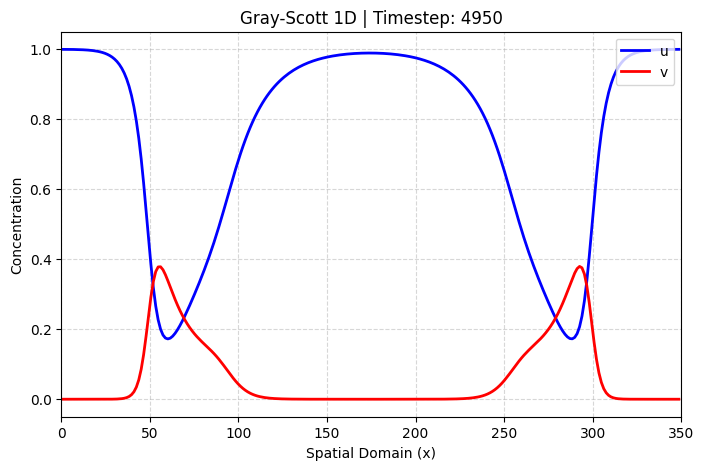

In [ ]:
# Parameters & Domain Setup

# Grid and Domain
L = 350.0          # Domain length
N = 256            # Number of spatial points
dx = L / N
x = np.linspace(0, L, N, endpoint=False)

# Time-stepping
dt = 0.1           # Time step (requires smaller dt for stability of explicit nonlinear part)
num_steps = 5000 # Total number of iterations
plot_every = 50   # Frame update interval for animation

# Gray-Scott Model Parameters (Soliton/Pulse splitting regime)
Du = 2
Dv = 1
F = 0.018
k = 0.047

snapshots = [0, 1500, 3000, 5000]

# Spectral Wavenumbers Setup

# numpy.fft.fftfreq returns the angular wavenumbers scaled by 2*pi
# k_vec = [0, 1, ..., N/2-1, -N/2, ..., -1] * (2*pi / L)
k_vec = np.fft.fftfreq(N, d=dx) * 2 * np.pi
k2 = k_vec**2 

# Precompute the denominators for the semi-implicit time step
# u_next = (u_curr + dt * Nonlinear) / u_denom
u_denom = 1.0 + dt * (Du * k2 + F)
v_denom = 1.0 + dt * (Dv * k2 + F + k)

# Precompute Fourier Transform of the constant 1 for the feed term F*(1 - u)
# In Fourier space, a constant is a Kronecker delta at k=0 scaled by N
F_one_hat = np.zeros(N)
F_one_hat[0] = F * N

# Initial Conditions (Uniform + Localized Seed)
# Initializing u and v with uniform steady state (f(u,v)=g(u,v)=0)
u = np.ones(N)
v = np.zeros(N)

# Add a big perturbation in the center
# This overcomes the stability of the trivial state
center_width = 20
start = N // 2 - center_width // 2 # Start index for the perturbation
end = N // 2 + center_width // 2 # End index for the perturbation

u[start:end] = 0.5
v[start:end] = 0.25

# Add small random noise to break symmetry
noise_amplitude = 0.02
u += np.random.uniform(-noise_amplitude, noise_amplitude, N)
v += np.random.uniform(-noise_amplitude, noise_amplitude, N)

# So concentrations don't accidentally dip below zero due to noise
u = np.clip(u, 0.0, 1.0)
v = np.clip(v, 0.0, 1.0)

# Transform initial conditions to Fourier Space
u_hat = np.fft.fft(u)
v_hat = np.fft.fft(v)

# Animation & Simulation Loop

fig, ax = plt.subplots(figsize=(8, 5))
line_u, = ax.plot(x, u, label='u', color='blue', lw=2)
line_v, = ax.plot(x, v, label='v', color='red', lw=2)

ax.set_ylim(-0.05, 1.05)
ax.set_xlim(0, L)
ax.set_xlabel('Spatial Domain (x)')
ax.set_ylabel('Concentration')
ax.set_title('Gray-Scott 1D Reaction-Diffusion (Fourier Spectral Method) ')
ax.legend(loc='upper right')
ax.grid(True, linestyle='--', alpha=0.5)
# Initialize the title template
title_template = 'Gray-Scott 1D | Timestep: {:d}'
ax.set_title(title_template.format(0))

def update(frame):
    global u_hat, v_hat
    current_step = frame * plot_every
    
    # 1. Bring back to real space for plotting First (so frame 0 shows true initial conditions)
    u_final = np.real(np.fft.ifft(u_hat))
    v_final = np.real(np.fft.ifft(v_hat))
    
    # 2. Update lines
    line_u.set_ydata(u_final)
    line_v.set_ydata(v_final)
    ax.set_title(title_template.format(current_step))
    
    # 3. Run 'plot_every' internal steps to prepare u_hat and v_hat for the NEXT frame
    for _ in range(plot_every):
        # Transform back to real space to compute the nonlinear term
        u_curr = np.real(np.fft.ifft(u_hat))
        v_curr = np.real(np.fft.ifft(v_hat))
        
        # Compute nonlinear reaction term: u * v^2
        nonlinear_real = u_curr * (v_curr**2) # compute in real space first
        nonlinear_hat = np.fft.fft(nonlinear_real)
        
        # Semi-Implicit Time Step Update formulas in Fourier Space
        u_hat_next = (u_hat + dt * (-nonlinear_hat + F_one_hat)) / u_denom
        v_hat_next = (v_hat + dt * nonlinear_hat) / v_denom
        
        # Update references
        u_hat = u_hat_next
        v_hat = v_hat_next

    return line_u, line_v

# Create animation
ani = animation.FuncAnimation(
    fig, update, frames=num_steps // plot_every, interval=20, blit=True
)

writer = animation.FFMpegWriter(fps=15, metadata=dict(artist='jesse'), bitrate=1800)

# Save the file
ani.save("gray_scott_1d.mp4", writer=writer)
plt.show()

Running 1D simulation and capturing publication snapshots...
Successfully saved multi-panel figure: gray_scott_1d_paper_F0.018_k0.047.pdf


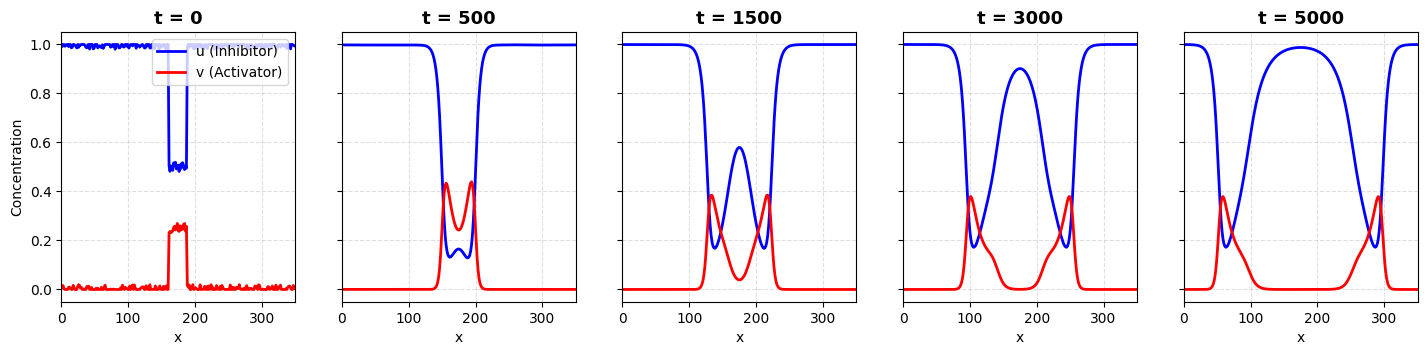

In [ ]:
# Local 1D Parameters & Coupling Setup
# Explicitly redefining everything here to avoid 2D variable pollution
L = 350.0          
N = 256            
dx = L / N
x = np.linspace(0, L, N, endpoint=False)

dt = 0.1           
snapshots = [0, 500, 1500, 3000, 5000]

Du, Dv = 2, 1
F, k = 0.018, 0.047
noise_amplitude = 0.02

# Recalculate 1D specific spectral vectors
k_vec = np.fft.fftfreq(N, d=dx) * 2 * np.pi
k2 = k_vec**2  

u_denom = 1.0 + dt * (Du * k2 + F)
v_denom = 1.0 + dt * (Dv * k2 + F + k)

F_one_hat = np.zeros(N)
F_one_hat[0] = F * N

# Initial Conditions

u = np.ones(N)
v = np.zeros(N)

center_width = 20
start = N // 2 - center_width // 2 
end = N // 2 + center_width // 2 
u[start:end] = 0.5
v[start:end] = 0.25

# Add the small random noise
u += np.random.uniform(-noise_amplitude, noise_amplitude, N)
v += np.random.uniform(-noise_amplitude, noise_amplitude, N)
u = np.clip(u, 0.0, 1.0)
v = np.clip(v, 0.0, 1.0)

u_hat = np.fft.fft(u)
v_hat = np.fft.fft(v)

# Plotting and Simulation Loop
num_plots = len(snapshots)
fig, axes = plt.subplots(1, num_plots, figsize=(3.5 * num_plots, 3.5), sharey=True)

if num_plots == 1:
    axes = [axes]

snapshot_idx = 0
max_step = max(snapshots)

print("Running 1D simulation and capturing publication snapshots...")

# Capture true t=0 before any time-stepping modifications happen
if 0 in snapshots:
    u_snapshot = np.real(np.fft.ifft(u_hat)).copy()
    v_snapshot = np.real(np.fft.ifft(v_hat)).copy()
    
    ax = axes[snapshot_idx]
    ax.plot(x, u_snapshot, label='u (Inhibitor)', color='blue', lw=2)
    ax.plot(x, v_snapshot, label='v (Activator)', color='red', lw=2)
    ax.set_title("t = 0", fontsize=13, fontweight='bold')
    ax.set_xlim(0, L)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel('x')
    ax.set_ylabel('Concentration')
    ax.legend(loc='upper right', frameon=True)
    ax.grid(True, linestyle='--', alpha=0.4)
    snapshot_idx += 1

# Step through timeline chronologically
for step in range(1, max_step + 1):
    u_curr = np.real(np.fft.ifft(u_hat))
    v_curr = np.real(np.fft.ifft(v_hat))
    
    nonlinear_real = u_curr * (v_curr**2)
    nonlinear_hat = np.fft.fft(nonlinear_real)
    
    # Update spectral arrays to the next time step
    u_hat = (u_hat + dt * (-nonlinear_hat + F_one_hat)) / u_denom
    v_hat = (v_hat + dt * nonlinear_hat) / v_denom

    # Capture the historical state if we match a milestone
    if step in snapshots:
        u_snapshot = np.real(np.fft.ifft(u_hat)).copy()
        v_snapshot = np.real(np.fft.ifft(v_hat)).copy()
        
        ax = axes[snapshot_idx]
        ax.plot(x, u_snapshot, color='blue', lw=2)
        ax.plot(x, v_snapshot, color='red', lw=2)
        
        ax.set_title(f"t = {step}", fontsize=13, fontweight='bold')
        ax.set_xlim(0, L)
        ax.set_ylim(-0.05, 1.05)
        ax.set_xlabel('x')
        ax.grid(True, linestyle='--', alpha=0.4)
        
        if snapshot_idx == 0:
            ax.set_ylabel('Concentration')
            ax.legend(loc='upper right', frameon=True)
            
        snapshot_idx += 1

# Save as PDF 
output_pdf = f"gray_scott_1d_paper_F{F:.3f}_k{k:.3f}.pdf"
plt.savefig(output_pdf, bbox_inches='tight', dpi=300)
print(f"Successfully saved multi-panel figure: {output_pdf}")
plt.show()

# **2-D**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy.fft import fft2, ifft2

def generate_gray_scott_animation(F, k, num_steps=6000, plot_every=20, fps=24):
    # Parameters & 2D Grid Setup
    Nx, Ny = 256, 256  
    Lx, Ly = 350.0, 350.0
    dx = Lx / Nx
    dy = Ly / Ny

    # Time-stepping step size
    dt = 1.0           
    Du, Dv = 2, 1

    # Create filenames based on parameters
    # Uses 3 decimal places to prevent messy float string formatting
    filename = f"gray_scott_F{F:.3f}_k{k:.3f}.mp4"
    
    # 2D Spectral Wavenumbers Setup
    kx = np.fft.fftfreq(Nx, d=dx) * 2 * np.pi
    ky = np.fft.fftfreq(Ny, d=dy) * 2 * np.pi
    Kx, Ky = np.meshgrid(kx, ky, indexing='ij')
    K2 = Kx**2 + Ky**2  

    u_denom = 1.0 + dt * (Du * K2 + F)
    v_denom = 1.0 + dt * (Dv * K2 + F + k)

    F_one_hat = np.zeros((Nx, Ny))
    F_one_hat[0, 0] = F * Nx * Ny

    # Initial Conditions (Uniform Baseline + Localized Seed)
    
    u = np.ones((Nx, Ny))
    v = np.zeros((Nx, Ny))

    # Add perturbation in the center
    center_width = 60
    start_x = Nx // 2 - center_width // 2 # Start index for the perturbation (//2 centers it and ensures it's an integer)
    end_x = Nx // 2 + center_width // 2 # End index for the perturbation
    start_y = Ny // 2 - center_width // 2
    end_y = Ny // 2 + center_width // 2

    u[start_x:end_x, start_y:end_y] = 0.50
    v[start_x:end_x, start_y:end_y] = 0.25

    noise_amplitude = 0.02
    u += np.random.uniform(-noise_amplitude, noise_amplitude, (Nx, Ny)) # Add small random noise to break perfect symmetry
    v += np.random.uniform(-noise_amplitude, noise_amplitude, (Nx, Ny))

    u = np.clip(u, 0.0, 1.0) # so concentrations don't dip below zero due to noise
    v = np.clip(v, 0.0, 1.0)

    u_hat = fft2(u)
    v_hat = fft2(v)

    # Animation Setup
    fig, ax = plt.subplots(figsize=(6, 6))
    img = ax.imshow(
        v, 
        cmap='inferno', 
        extent=[0, Lx, 0, Ly], 
        origin='lower', 
        vmin=0.0, 
        vmax=0.5
    )

    ax.set_xlabel('Spatial Domain X')
    ax.set_ylabel('Spatial Domain Y')
    fig.colorbar(img, ax=ax, label='Concentration of v')

    title_template = f'Gray-Scott 2D (F={F:.3f}, k={k:.3f}) | Timestep: {{:d}}'
    ax.set_title(title_template.format(0))

    # Explicitly clear variables inside the closure scope using nonlocal
    def update(frame):
        nonlocal u_hat, v_hat
        current_step = frame * plot_every
        
        for _ in range(plot_every):
            u_curr = np.real(ifft2(u_hat))
            v_curr = np.real(ifft2(v_hat))
            
            nonlinear_real = u_curr * (v_curr**2)
            nonlinear_hat = fft2(nonlinear_real)
            
            u_hat = (u_hat + dt * (-nonlinear_hat + F_one_hat)) / u_denom
            v_hat = (v_hat + dt * nonlinear_hat) / v_denom

        v_final = np.real(ifft2(v_hat))
        img.set_array(v_final)
        ax.set_title(title_template.format(current_step))
        
        return [img]

    total_frames = num_steps // plot_every
    ani = animation.FuncAnimation(
        fig, update, frames=total_frames, interval=1000//fps, blit=False
    )

    # Save the animation
    writer = animation.FFMpegWriter(fps=fps, bitrate=2000)
    ani.save(filename, writer=writer)
    plt.close(fig) # Closes the figure memory footprint so it doesn't leak between runs

In [ ]:
# Different values of F and k animations

if __name__ == "__main__":
    # Test Case 1: Standard Soliton/Spot Division Regime
    #generate_gray_scott_animation(F=0.035, k=0.060)
    
    # Test Case 2: Coral-like / Fingerprint Stripe Regime
    # generate_gray_scott_animation(F=0.042, k=0.065)
    
    # Test Case 3: Chaotic/Turbulent Dynamic Waves Regime
    # generate_gray_scott_animation(F=0.025, k=0.053)

    # generate_gray_scott_animation(F=0.033, k=0.033)

    #generate_gray_scott_animation(F=0.044, k=0.060)

    generate_gray_scott_animation(F=0.062, k=0.0609)

In [ ]:
def export_paper_snapshots(F, k, snapshots=[0, 200, 1000, 6000]):
    # Grid & Physics Setup
    Nx, Ny = 256, 256
    Lx, Ly = 350.0, 350.0
    dx, dy = Lx / Nx, Ly / Ny
    dt = 1
    Du, Dv = 2.0, 1.0

    # Spectral Setup
    kx = np.fft.fftfreq(Nx, d=dx) * 2 * np.pi
    ky = np.fft.fftfreq(Ny, d=dy) * 2 * np.pi
    Kx, Ky = np.meshgrid(kx, ky, indexing='ij')
    K2 = Kx**2 + Ky**2
    u_denom = 1.0 + dt * (Du * K2 + F)
    v_denom = 1.0 + dt * (Dv * K2 + F + k)
    F_one_hat = np.zeros((Nx, Ny))
    F_one_hat[0, 0] = F * Nx * Ny

    # Initial Conditions (Seed Patch + Noise)
   # Initial Conditions (Uniform Baseline + Localized Seed)
    
    u = np.ones((Nx, Ny))
    v = np.zeros((Nx, Ny))

    # Add perturbation in the center
    center_width = 60
    start_x = Nx // 2 - center_width // 2 # Start index for the perturbation (//2 centers it and ensures it's an integer)
    end_x = Nx // 2 + center_width // 2 # End index for the perturbation
    start_y = Ny // 2 - center_width // 2
    end_y = Ny // 2 + center_width // 2

    u[start_x:end_x, start_y:end_y] = 0.50
    v[start_x:end_x, start_y:end_y] = 0.25

    noise_amplitude = 0.02
    u += np.random.uniform(-noise_amplitude, noise_amplitude, (Nx, Ny)) # Add small random noise to break perfect symmetry
    v += np.random.uniform(-noise_amplitude, noise_amplitude, (Nx, Ny))

    u = np.clip(u, 0.0, 1.0) # so concentrations don't dip below zero due to noise
    v = np.clip(v, 0.0, 1.0)

    
    u_hat = fft2(u)
    v_hat = fft2(v)

    # Setup the Multi-Panel Plot Layout (1 Row, N Columns)
    num_plots = len(snapshots)
    fig, axes = plt.subplots(1, num_plots, figsize=(4 * num_plots, 4), sharey=True)
    
    # Ensure axes is iterable even if only 1 snapshot is requested
    if num_plots == 1:
        axes = [axes]

    snapshot_idx = 0
    max_step = max(snapshots)

    print("Running simulation to collect paper snapshots...")
    for step in range(max_step + 1):
        # If the current step matches a requested snapshot, save the visual array
        if step in snapshots:
            v_current = np.real(ifft2(v_hat))
            ax = axes[snapshot_idx]
            
            # Draw the heatmap for this specific step
            im = ax.imshow(v_current, cmap='inferno', extent=[0, Lx, 0, Ly], origin='lower', vmin=0.0, vmax=0.5)
            ax.set_title(f"t = {step}", fontsize=14)
            ax.set_xlabel("x")
            if snapshot_idx == 0:
                ax.set_ylabel("y")
            
            snapshot_idx += 1

        # Run the standard pseudospectral step
        u_curr = np.real(ifft2(u_hat))
        v_curr = np.real(ifft2(v_hat))
        nonlinear_hat = fft2(u_curr * (v_curr**2))
        
        u_hat = (u_hat + dt * (-nonlinear_hat + F_one_hat)) / u_denom
        v_hat = (v_hat + dt * nonlinear_hat) / v_denom

    # Add a single shared colorbar at the right end of the figure
    fig.subplots_adjust(right=0.85)
    cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])
    fig.colorbar(im, cax=cbar_ax, label="Activator Concentration (v)")
    
    # Save as a pdf
    output_name = f"gray_scott_paper_F{F:.3f}_k{k:.3f}.pdf"
    plt.savefig(output_name, bbox_inches='tight', dpi=300)
    print(f"Saved publication figure: {output_name}")
    plt.show()

In [ ]:
export_paper_snapshots(F=0.042, k=0.065, snapshots=[0, 500, 2000, 6000])